Epoch 1/150


E0000 00:00:1783355444.137076   14611 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 4.5759 - mae: 1.8503 - rmse: 2.1383 - val_loss: 2.5907 - val_mae: 1.3476 - val_rmse: 1.6085 - learning_rate: 5.0000e-04
Epoch 2/150
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6403 - mae: 1.3613 - rmse: 1.6238 - val_loss: 1.2955 - val_mae: 0.8853 - val_rmse: 1.1367 - learning_rate: 5.0000e-04
Epoch 3/150
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4318 - mae: 0.9283 - rmse: 1.1952 - val_loss: 0.6618 - val_mae: 0.5665 - val_rmse: 0.8114 - learning_rate: 5.0000e-04
Epoch 4/150
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9768 - mae: 0.7460 - rmse: 0.9866 - val_loss: 0.5333 - val_mae: 0.5053 - val_rmse: 0.7279 - learning_rate: 5.0000e-04
Epoch 5/150
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8163 - mae: 0.6795 - rmse: 0.9016 - val_loss: 0.5486 - val_mae: 0.5049 - val_rmse: 0.7383 - learning_rate: 5.0000e-04
Epoch 6/150
207/207 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7340 - mae: 0.6405 - rmse: 0.8547 - val_loss

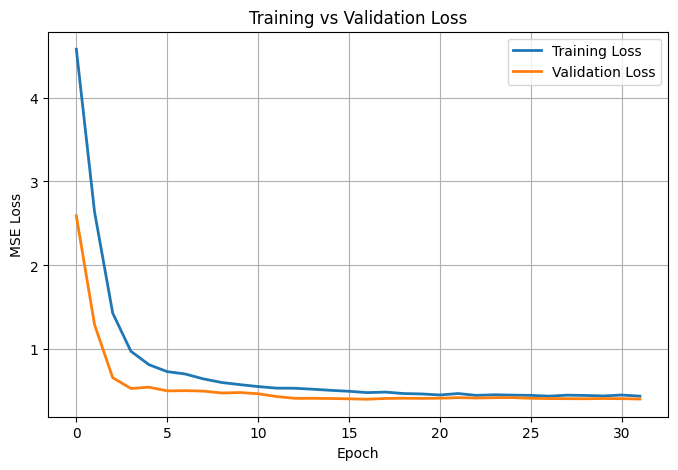

In [2]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from math import sqrt

# -------------------------------------------------------------------
# Reproducibility
# -------------------------------------------------------------------
np.random.seed(42)
tf.random.set_seed(42)
tf.config.experimental.enable_op_determinism()

# -------------------------------------------------------------------
# Load Dataset
# -------------------------------------------------------------------
housing = fetch_california_housing()

X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data,
    housing.target,
    test_size=0.2,
    random_state=42
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42
)

# -------------------------------------------------------------------
# Feature Scaling
# -------------------------------------------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

# -------------------------------------------------------------------
# Model
# -------------------------------------------------------------------
l2 = keras.regularizers.l2(1e-4)

model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),

    keras.layers.Dense(
        32,
        activation="relu",
        kernel_regularizer=l2
    ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.20),

    keras.layers.Dense(
        16,
        activation="relu",
        kernel_regularizer=l2
    ),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.15),

    keras.layers.Dense(1)
])

# -------------------------------------------------------------------
# Compile
# -------------------------------------------------------------------
optimizer = keras.optimizers.AdamW(
    learning_rate=5e-4,
    weight_decay=1e-4
)

model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=[
        keras.metrics.RootMeanSquaredError(name="rmse"),
        keras.metrics.MeanAbsoluteError(name="mae")
    ]
)

# -------------------------------------------------------------------
# Callbacks
# -------------------------------------------------------------------
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

# -------------------------------------------------------------------
# Train
# -------------------------------------------------------------------
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    epochs=150,
    batch_size=64,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# -------------------------------------------------------------------
# Evaluate
# -------------------------------------------------------------------
test_loss, test_rmse, test_mae = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

predictions = model.predict(X_test, verbose=0).flatten()

r2 = r2_score(y_test, predictions)

print("\n========== Test Results ==========")
print(f"MSE  : {test_loss:.4f}")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAE  : {test_mae:.4f}")
print(f"R²   : {r2:.4f}")

# -------------------------------------------------------------------
# Plot
# -------------------------------------------------------------------
plt.figure(figsize=(8,5))

plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.grid(True)
plt.legend()

plt.show()
